# QA Baseline — 3 conditions x 5 genres

Runs the QA model over all 5 evaluation genres (wiki, news, statute,
case-law, novel) under 3 conditions — **closed_book** (question only),
**full_context** (whole corpus given), **chunked_sequential** (chunks
shown one at a time, up to 4, early-stop once confident) — and compares
accuracy/efficiency (API calls, time, tokens) across both genre and
condition. This is the project's main comparative experiment — it tests
whether the chunked_sequential reading strategy actually holds up against
the two baselines across genres, as opposed to `02_length_stress_test.ipynb`
which only varies document length within a single genre (novel) and never
exercises chunked_sequential at all.

Two answer formats coexist because the genres' native tasks differ:
- **extractive** (wiki, news, statute, novel) — open-ended short-answer,
  scored by normalized substring match (same as
  `02_length_stress_test.ipynb`).
- **multiple_choice** (case-law, from `lex_glue`'s native 5-option
  CaseHOLD format) — scored by parsing a 1-5 number (same style as this
  notebook's original 4-option Korean version, generalized to 5 options).

All 5 corpora were built by `data/scripts/build_{wiki,news,statute,
caselaw}_eval_corpus.py`; novel reuses `01_length_stress_prep.ipynb`'s
narrativeqa document + question set directly rather than building a
separate corpus (no need to duplicate that work).

In [1]:
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import pandas as pd
import requests
import yaml
from tqdm.auto import tqdm

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅


/Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Genre configs + data load

In [2]:
GENRES = {
    "wiki": {
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "format": "extractive",
    },
    "news": {
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "questions_path": "data/sample/news_eval_questions.csv",
        "format": "extractive",
    },
    "statute": {
        "corpus_path": "data/processed/statute_eval/statute_eval_corpus.txt",
        "questions_path": "data/sample/statute_eval_questions.csv",
        "format": "extractive",
    },
    "novel": {
        "corpus_path": "data/processed/narrativeqa_length_stress/length_stress_corpus.txt",
        "questions_path": "data/sample/narrativeqa_length_stress.csv",
        "format": "extractive",
    },
    "caselaw": {
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "format": "multiple_choice",
    },
}

corpora: dict[str, str] = {}
questions: dict[str, pd.DataFrame] = {}

for genre, cfg in GENRES.items():
    with open(cfg["corpus_path"], encoding="utf-8") as f:
        corpora[genre] = f.read()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    questions[genre] = qdf
    print(f"{genre:10} format={cfg['format']:16} corpus={len(corpora[genre].split()):>6} words, questions={len(qdf):>4}")

wiki       format=extractive       corpus= 14934 words, questions= 100
news       format=extractive       corpus= 12428 words, questions= 100
statute    format=extractive       corpus= 14250 words, questions=  11
novel      format=extractive       corpus= 63658 words, questions=  21
caselaw    format=multiple_choice  corpus= 13790 words, questions= 100


## 2. Chunking (for chunked_sequential)

One `paginate_semantic` chunk set per genre corpus, built once and reused
across all conditions/questions for that genre.

In [3]:
chunks_by_genre: dict[str, list] = {}

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY — skipping chunk generation (chunked_sequential will be unavailable).")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts, load_config

    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    embed_cfg = load_config("configs/importance_filter.yaml")

    for genre, text in corpora.items():
        paragraphs = plain_text_to_paragraphs(text)
        chunks_by_genre[genre] = paginate_semantic(
            paragraphs,
            min_words=chunk_cfg["min_words"],
            max_words=chunk_cfg["max_words"],
            granularity="paragraph",
            config=embed_cfg,
            embed_fn=embed_texts,
        )
        print(f"{genre:10} chunks: {len(chunks_by_genre[genre])}")

wiki       chunks: 61
news       chunks: 52
statute    chunks: 65
novel      chunks: 255
caselaw    chunks: 100


## 3. NIM chat API call (`call_chat`)

Same implementation used throughout this project's notebooks: sliding-window
rate limiter (30/min), exponential backoff, thread-local usage tracking.

In [4]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 4. Message builders + scoring (both formats)

In [5]:
_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool — answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."
_CONTINUE_SIGNAL = "CONTINUE"
MAX_CHUNKS_EXPLORE = 4


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        pred_idx = parse_option_number(prediction)
        return pred_idx is not None and (pred_idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options_text = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options_text}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}


def build_messages_closedbook(genre: str, row: pd.Series) -> list[dict]:
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions."}
    return [system, _question_turn(genre, row)]


def build_messages_fullcontext(genre: str, row: pd.Series) -> list[dict]:
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions."}
    context = {
        "role": "user",
        "content": f"Read the following text, then answer the question after it.\n\n{corpora[genre]}",
    }
    return [system, context, _question_turn(genre, row)]


def run_chunked_sequential(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Shows chunks one at a time (up to MAX_CHUNKS_EXPLORE); the model answers
    as soon as it's confident, or outputs CONTINUE to see the next chunk. If
    still unresolved after the last chunk, it must answer anyway."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You'll be shown the "
            f"source text one chunk at a time (up to {MAX_CHUNKS_EXPLORE}). After each chunk, if you're "
            f"already confident, output {answer_hint}; if not yet confident and want to see the next "
            f"chunk, output only '{_CONTINUE_SIGNAL}'."
        ),
    }
    messages = [system, _question_turn(genre, row)]

    explore_chunks = chunks_by_genre[genre][:MAX_CHUNKS_EXPLORE]
    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    prediction = None
    chunks_used = 0

    for i, c in enumerate(explore_chunks):
        is_last = i == len(explore_chunks) - 1
        instruction = (
            f"This is the last chunk you'll see — you must answer now ({answer_hint})."
            if is_last
            else f"If you can answer now, do so ({answer_hint}); otherwise output only '{_CONTINUE_SIGNAL}'."
        )
        messages.append(
            {"role": "user", "content": f"[chunk {i + 1}/{len(explore_chunks)}]\n{c.text}\n\n{instruction}"}
        )

        t0 = time.time()
        reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        chunks_used = i + 1

        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        messages.append({"role": "assistant", "content": reply})

        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        looks_like_continue = fmt != "multiple_choice" and _CONTINUE_SIGNAL.lower() in reply.strip().lower()
        if fmt == "multiple_choice":
            if candidate is not None:
                prediction = str(candidate)
                break
        elif not looks_like_continue and candidate:
            prediction = candidate
            break

    return {
        "prediction": prediction,
        "api_calls": chunks_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 5. Experiment loop — genre x condition x question

Parallelized per-question with `ThreadPoolExecutor`. Checkpointed per
`(genre, condition)` pair.

In [6]:
RESULTS_PATH = "results/qa_baseline_3conditions.csv"
CONDITIONS = ["closed_book", "full_context", "chunked_sequential"]
MAX_WORKERS = 8


def _run_single_call_condition(genre: str, condition: str, row: pd.Series) -> dict:
    if condition == "closed_book":
        messages = build_messages_closedbook(genre, row)
    else:
        messages = build_messages_fullcontext(genre, row)

    t0 = time.time()
    reply = call_chat(messages, model=QA_MODEL, api_key=QA_API_KEY, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    return {
        "prediction": reply.strip(),
        "api_calls": 1,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }


def _run_one_question(genre: str, condition: str, row: pd.Series) -> dict:
    try:
        if condition == "chunked_sequential":
            outcome = run_chunked_sequential(genre, row, QA_MODEL, QA_API_KEY)
        else:
            outcome = _run_single_call_condition(genre, condition, row)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}/{condition}] question {row['question_id']} failed: {type(e).__name__}: {e}")

    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": condition,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RESULTS_PATH} ({len(existing_df)} rows)")
else:
    existing_df = pd.DataFrame()

done_pairs = set()
if len(existing_df):
    for (genre, condition), group in existing_df.groupby(["genre", "condition"]):
        if len(group) >= len(questions[genre]):
            done_pairs.add((genre, condition))

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY — skipping the experiment loop.")
    results_df = existing_df
else:
    results = existing_df.to_dict("records")
    for genre in GENRES:
        for condition in CONDITIONS:
            if (genre, condition) in done_pairs:
                print(f"skip (already done): {genre}/{condition}")
                continue
            if condition == "chunked_sequential" and genre not in chunks_by_genre:
                print(f"skip (no chunks available): {genre}/{condition}")
                continue

            qdf = questions[genre]
            print(f"running: {genre}/{condition} ({len(qdf)} questions)")
            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
                futures = [executor.submit(_run_one_question, genre, condition, row) for _, row in qdf.iterrows()]
                for future in tqdm(as_completed(futures), total=len(futures), desc=f"{genre}/{condition}"):
                    results.append(future.result())

            pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)

    results_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(results_df)}")

loaded checkpoint: results/qa_baseline_3conditions.csv (996 rows)
skip (already done): wiki/closed_book
skip (already done): wiki/full_context
skip (already done): wiki/chunked_sequential
skip (already done): news/closed_book
skip (already done): news/full_context
skip (already done): news/chunked_sequential
skip (already done): statute/closed_book
skip (already done): statute/full_context
skip (already done): statute/chunked_sequential
skip (already done): novel/closed_book
skip (already done): novel/full_context
skip (already done): novel/chunked_sequential
skip (already done): caselaw/closed_book
skip (already done): caselaw/full_context
skip (already done): caselaw/chunked_sequential

total results: 996


## 6. Analysis — accuracy by genre x condition

In [7]:
if results_df.empty:
    print("No results to analyze.")
else:
    accuracy = results_df.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
    accuracy = accuracy.reindex(list(GENRES.keys()))[CONDITIONS]
    n = results_df.pivot_table(index="genre", columns="condition", values="correct", aggfunc="count")
    n = n.reindex(list(GENRES.keys()))[CONDITIONS]
    print("accuracy:")
    print(accuracy)
    print("\nn (denominator):")
    print(n)

accuracy:
condition  closed_book  full_context  chunked_sequential
genre                                                   
wiki          0.320000      0.800000            0.220000
news          0.000000      0.450000            0.020000
statute       0.000000      0.454545            0.090909
novel         0.047619      0.285714            0.285714
caselaw       0.270000      0.370000            0.290000

n (denominator):
condition  closed_book  full_context  chunked_sequential
genre                                                   
wiki               100           100                 100
news               100           100                 100
statute             11            11                  11
novel               21            21                  21
caselaw            100           100                 100


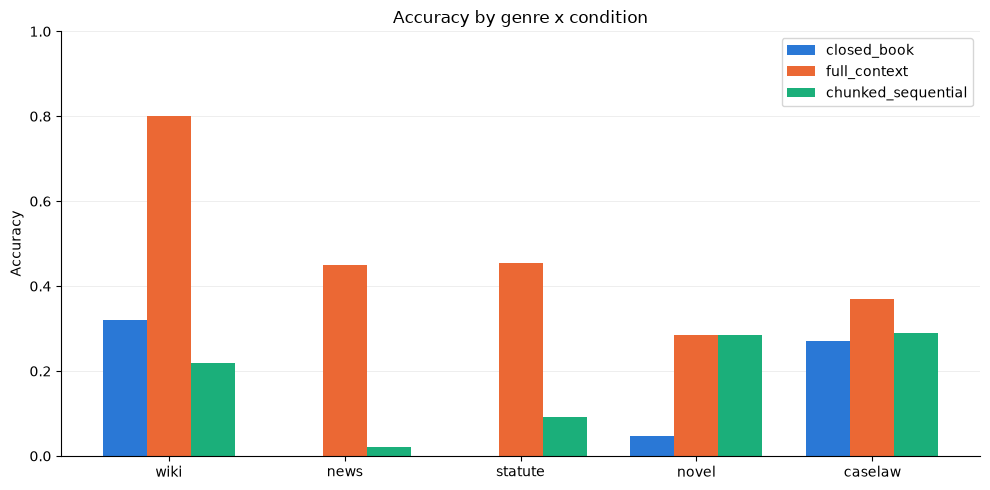

In [8]:
if not results_df.empty:
    CONDITION_COLORS = {"closed_book": "#2a78d6", "full_context": "#eb6834", "chunked_sequential": "#1baf7a"}
    x = range(len(accuracy))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, condition in enumerate(CONDITIONS):
        ax.bar([xi + i * bar_width for xi in x], accuracy[condition], width=bar_width,
               label=condition, color=CONDITION_COLORS[condition])
    ax.set_xticks([xi + bar_width for xi in x])
    ax.set_xticklabels(accuracy.index)
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy by genre x condition")
    ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Analysis — efficiency (API calls, time, tokens) by condition

In [9]:
if not results_df.empty:
    efficiency = results_df.groupby("condition").agg(
        accuracy=("correct", "mean"),
        avg_api_calls=("api_calls", "mean"),
        avg_seconds=("elapsed_seconds", "mean"),
        avg_total_tokens=("total_tokens", "mean"),
    )
    efficiency = efficiency.reindex(CONDITIONS)
    efficiency

## Interpretation notes

**full_context wins in every genre** except a tie with chunked_sequential in
`novel` (§6): wiki 0.80 vs. 0.32/0.22, news 0.45 vs. 0.00/0.02, statute
0.455 vs. 0.00/0.091, caselaw 0.37 vs. 0.27/0.29, novel 0.286 = 0.286 vs.
closed_book's 0.048.

**chunked_sequential does not beat full_context anywhere**, and in
aggregate its overall accuracy (18.1%) is statistically indistinguishable
from closed_book's (18.1%, §7) — while costing ~3.5x the API calls, ~3.7x
the wall time, and ~26x the tokens (151 → 3,886 avg tokens/question) of
closed_book. That aggregate tie is genre-dependent, not uniform, though:
- **novel** — chunked_sequential (0.286) clearly beats closed_book (0.048)
  and matches full_context. This is the one genre where the corpus (63,658
  words, 254 chunks) is far too long to meaningfully differ from
  full_context in practice, and where reading even a handful of chunks
  sequentially beats reading nothing.
- **wiki/news/statute** — corpora here are all a single-context-window size
  (12,000-15,000 words), which is exactly why full_context does so well.
  Restricting to 4 sequentially-explored chunks with early-stop loses real
  information relative to seeing everything, and the 4-chunk budget doesn't
  reliably land on the evidence — chunked_sequential trails full_context by
  the widest margins in precisely these three genres.
- **caselaw** — closed_book (0.27) is already comfortably above the 20%
  random floor for a 5-option task, suggesting some of this is the model's
  prior legal-reasoning ability rather than evidence use; chunked_sequential
  (0.29) barely edges past it, and the full_context gap (0.37) is
  correspondingly the smallest of the four extractive/MC genres.

**Takeaway**: as tested here, chunked_sequential is a *raw* sequential-chunk
baseline — no rehearsal/gisting compression is applied to what's shown at
each step, it's just the plain source chunk with an early-stop budget. That
it doesn't beat full_context, and only clearly beats closed_book on the one
genre where full_context itself becomes impractical (novel), is a fair
negative/mixed result at this stage rather than a bug — it's the
uncompressed control condition the project's actual rehearsal/gisting
pipeline (once trained and wired in, per `04`-`09`) needs to beat in order
to justify itself.

## Note on scale

This covers 5 genres x 3 conditions, with per-genre question counts of ~100
(wiki, news, caselaw), ~21 (novel), ~11 (statute) — 996 (genre, condition,
question) triples total, and chunked_sequential can take up to 4 sequential
API calls per question. The full run took roughly an hour wall-clock
(dominated by the two 100-question chunked_sequential genres, wiki and
caselaw, at ~13 minutes each, driven by both the multi-call-per-question
cost and this NIM endpoint's latency variance — anywhere from ~5s to 120s+
per call this session). §5's per-(genre, condition) checkpointing means a
partial/interrupted run resumes cleanly rather than redoing completed
pairs.